In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")


### Schema
When we defined a langgraph StateGraph, we use a state schema
- The state schema represents the strucutre and types of data that our graph will use.
- All nodes are expected to communicate with that schema
- Langgraph offers flexbility in how you define your state schema, accomodating various python types and validation approaches


##### TypedDict
Previously, we used TypedDict class from python's typing module, it allows to specify keys and their corresponding value types

*But these are type hints*

- They can used by static type checkers (like mypy), but they are not enforced at runtime

In [2]:
from typing_extensions import TypedDict

class TypedDictState(TypedDict):
    foo: str
    bar: str

In [3]:
choco_bars: TypedDictState = TypedDictState(company="Choco", bar="M&Ms")
print(choco_bars["bar"])
print(choco_bars["company"])

M&Ms
Choco


*For more specific value constraints, we can use things like Literal type hint*

In [4]:
from typing import Literal

class TypeDictState(TypedDict):
    name: str
    mood: Literal["happy", "sad"]

In [5]:
override_mood: TypeDictState = TypeDictState(name="Moiz", mood="mad", random_field="user")
override_mood["mood"]
print(override_mood)

{'name': 'Moiz', 'mood': 'mad', 'random_field': 'user'}


*We can use our defined state class (e.g., TypedDictState) in LangGraph by simply passing it to StateGraph*

- and we can think about each state key just a "channel" in our graph.
- Previosuly we saw, we overwrite the value of a specified key or "channel" in each node

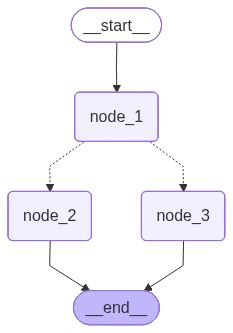

In [6]:
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph

def node_1(state: TypeDictState):
    print("---Node 1---")
    return {"name": state["name"] + " is ..."}

def node_2(state: TypeDictState):
    print("---Node 2---")
    return {"mood": "mad"}

def node_3(state: TypeDictState):
    print("---Node 3---")
    return {"mood": "Sad"}

def decide_mood(state: TypeDictState) -> Literal["node_2", "node_3"]:
    # do 50/50 split
    if random.random() < 0.5:
        return "node_2"
    
    return "node_3"

# Build Graph
builder: StateGraph = StateGraph(TypeDictState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph: CompiledStateGraph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

*b/c our state is a dict, we simply invoke the graph with a dict to set an initial value of the name key in our state*

In [7]:
graph.invoke({"name": "Moiz"})


---Node 1---
---Node 3---


{'name': 'Moiz is ...', 'mood': 'Sad'}

##### Dataclass
Python's dataclass provide another way to define strucutre data
- Dataclasses offer a concise syntax for creating classes that are primarily used to store data

In [8]:
from dataclasses import dataclass

@dataclass
class DataClassState:
    name: str
    mood: Literal["happy", "sad"]

In [9]:
# no_name: DataClassState = DataClassState(mood="mad")
# print(no_name)
#TypeError: DataClassState.__init__() missing 1 reqired positional argument: 'name'

no_name: DataClassState = DataClassState(mood="mad", name="moiz")
print(no_name)

DataClassState(name='moiz', mood='mad')


To access the keys of a dataclass, we just need to modify the subscripting used in node_1:
- We use state.name for the dataclass state rather than state ["name] for the TypedDict above
- Here'a a catch, in each node we still return a dictionary to perform the state updates

*This is possible b/c LangGraph stores each key of your state object separately*

The object returned by the node only needs to have keys (attributes) that match those in the state

*In this case, the dataclass has key **name** so we can update it by passing a dict from our node, just as we did when state was a TypedDict*

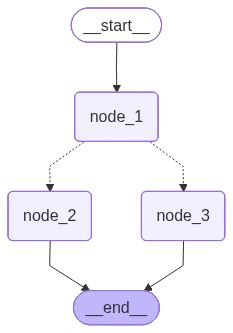

In [10]:
def node_1(state: DataClassState) -> dict:
    print("---Node 1---")
    return {"name": state.name + " is ..."}

def node_2(state: DataClassState) -> dict:
    print("---Node 2---")
    return {"mood": "happy"}

def node_3(state: DataClassState) -> dict:
    print("---Node 3---")
    return {"mood": "sad"}

# Build Graph
builder: StateGraph =  StateGraph(DataClassState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph: DataClassState = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

*We invoke with a **dataclass** to set the  intial values of each key/channel in our state*

In [11]:
graph.invoke(DataClassState(name="Moiz", mood="sad"))


---Node 1---
---Node 2---


{'name': 'Moiz is ...', 'mood': 'happy'}

In [12]:
graph.invoke({"name": "Moiz", "mood": "still not enforced", "random_field": "user"})

---Node 1---
---Node 2---


{'name': 'Moiz is ...', 'mood': 'happy'}

##### Pydantic
Previously TypedDict and Dataclasses, they provide type hints but don't enforce types at runtime
- Means we could potentially assign invalid values without raising an error
- *For example we set mood to mad even though our type hint specifies mood: list[Literal["happy", "sad"]]*

Pydantic is a data validation and settings management ibrary using python type annotations
- It's particularly well-suited for defining state schemas in Langgraph due to it's validation capabilities.
- Pydantic can perform validation to check wether data confirms to the specified types and contraints at runtime



In [13]:
from pydantic import BaseModel, field_validator, ValidationError

class PydanticState(BaseModel):
    name: str
    mood: Literal ["happy", "sad"]

    @field_validator('mood')
    @classmethod
    def validate_mood(cls, value):
        if value not in ["happy", "sad"]:
            raise ValueError("Each mood must be either happy or sad")
        
        return value
    
try:
    state = PydanticState(name="Moiz Ali", mood="mad")
except ValidationError as e:
    print("Validation Errot", e)

Validation Errot 1 validation error for PydanticState
mood
  Input should be 'happy' or 'sad' [type=literal_error, input_value='mad', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/literal_error


*We can use Pydantic State in our graoh seamlessly*

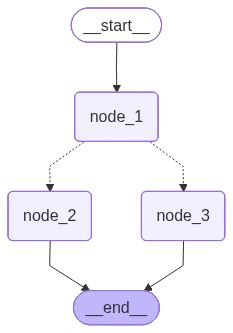

In [14]:
def node_1(state: PydanticState):
    print("---Node 1---")
    return {"name": state.name + " is ..."}

def node_2(state: PydanticState):
    print("---Node 2---")
    return {"mood": "happy"}

def node_3(state: PydanticState):
    print("---Node 3---")
    return {"mood": "sad"}

def decide_mood(state: PydanticState) -> Literal["node_2", "node_3"]:
    if random.random() < 0.5:
        return "node_2"
    
    return "node_3"

# Build Graph
builder: StateGraph = StateGraph(PydanticState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# ADD
graph: CompiledStateGraph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
graph.invoke(PydanticState(name="Moiz", mood="sad"))
# graph.invoke(PydanticState(name="Moiz", mood="mad")) # gives error b/c we use pydantic

---Node 1---
---Node 3---


{'name': 'Moiz is ...', 'mood': 'sad'}

### A Pydantic ReAct Agent

In [16]:
from langchain_core.tools import tool

@tool
def search(query: str) -> str:
    """Call to Surf the Web"""
    # This is the placeholder for actual implementation
    # LLM don't know this

    return "The answer to your question lies within."


tools = [search]

In [17]:
from langgraph.prebuilt import ToolNode

tool_node: ToolNode = ToolNode(tools)

In [18]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
model: ChatGoogleGenerativeAI = llm.bind_tools(tools)

In [19]:
import operator
from pydantic import BaseModel
from typing import Annotated, Sequence
from langchain_core.messages import BaseMessage

class AgentState(BaseModel):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [20]:
# Define the function that determines whether to conitnue or not
def should_continue(state: AgentState) -> Literal["end", "continue"]:
    messages = state.messages
    last_message = messages[-1]
    # if there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    
    # otherwise, we continue
    else:
        return "continue"
    
# Define the function that calls the model
def call_model(state: AgentState):
    messages = state.messages
    response = model.invoke(messages)

    # we return a list, b/c this will get added to the existing list
    return {"messages": [response]}

In [21]:
from langgraph.graph import StateGraph, START, END

# Define a new graph
workflow: StateGraph = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("action", tool_node)

# Set the entrypoint as agent
# means this node is the first one called
workflow.add_edge(START, "agent")

# We now add a conditional edge
workflow.add_conditional_edges(
    # First we define the start node, we use 'agent'
    # Means these are te edges taken after the 'agent' node is called
    "agent",

    # Next we pass in the function that will determine which node is called next
    should_continue,
    # Finally we pass in the mapping
    # The keys are strings, and the value are other nodes
    # END is a special node marking that the graph should finish
    # What will happen is we will call 'should_continue', and then the output of that
    # Will be matched against the keys in this mapping
    # Based om which one it matches, that node will then be called
    {
        # if 'tools', then we call the tool_node
        "continue": "action",
        # otherwise, we finsih
        "end": END,
    }
)

# We now add a normal edge from 'tools' to 'agent'
# Means that after 'tools' is called, 'agent' node is called next
workflow.add_edge("action", "agent")

# then compile it
# this compiles it into runnables
# means we can use it as you would any other runnables
app: CompiledStateGraph = workflow.compile()


In [22]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'agent': Node(id='agent', name='agent', data=agent(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'action': Node(id='action', name='action', data=tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'search': StructuredTool(name='search', description='Call to Surf the Web', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000028A548E3E20>)}, _injected_args={'search': _InjectedArgs(state={}, store=None, runtime=None, all_injected_keys=set(), _optional_state_args=set())}, _handle_tool_errors=<function _default_handle_tool_errors at 0x0000028A55CF1580>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None), metadata=None)

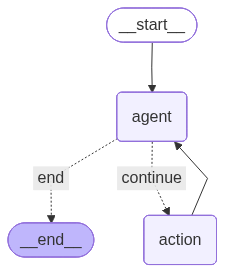

In [23]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
from langchain_core.messages import HumanMessage

inputs = {"messages": [HumanMessage(content="Search the tool for what is the weather in Isb")]}
for chunk in app.stream(inputs, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Search the tool for what is the weather in Isb
================================== Ai Message ==================================
Tool Calls:
  search (67a18c6f-41af-4f57-9a7e-b565e4e1f920)
 Call ID: 67a18c6f-41af-4f57-9a7e-b565e4e1f920
  Args:
    query: weather in Islamabad
================================= Tool Message =================================
Name: search

The answer to your question lies within.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'I am sorry, I cannot tell you what the weather is.', 'extras': {'signature': 'CpkGAQw51sfmA44R9mUubUdbd2w/HJlQwwblaLhJs3mdJZp1EBRypQeFjUB9YD56Sj+SRd4RWhqucwsPgYLNpu1ZcwsVFFUnEUaiad71h6cIsynnnBOljUo1xTs2bnT2tE6/LvCeuI6teQR089ae9bxiofPUpGVJNC2sgsW2kyHRMP4leUNRVKtOIx8hw33L41v/La7OFAUtJREAv7wVlAP1tWX3qYyyq7ERpn6dLWLEROoHpNh6cHDydwgyZqAUm2yrpSU8Lo5mYfR58F5EwgDn/ESSThatm5rvR5FG7/aAi1f9lQUuMgQt0ajJ2ii9

### State Reducers

##### Default Overwriting state

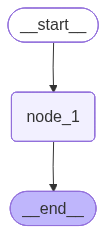

In [25]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph

class State(TypedDict):
    foo: int

def node_1(state: State) -> dict:
    print("---Node 1---")
    return {"foo": state['foo'] + 1}

# Build Graph
builder: StateGraph = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph: CompiledStateGraph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
graph.invoke(State(foo = 1))

---Node 1---


{'foo': 2}

##### Now branching...

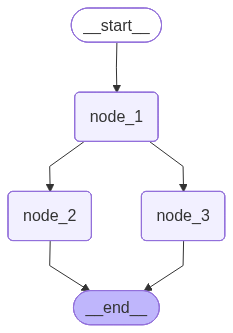

In [27]:
def node_1(state: State):
    print("---Node 1---")
    return {"foo": [state['foo'][-1] + 1]}

def node_2(state: State):
    print("---Node 2---")
    return {"foo": [state["foo"][-1] + 1]}

def node_3(state: State):
    print("---Node 3---")
    return {"foo": [state['foo'][-1] + 1]}

# Build Graph
builder: StateGraph = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph: CompiledStateGraph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

*updates in node 2 and node 3 are performed concurrently because they are in the same step*

In [28]:
#graph.invoke({"foo": [1]})

If we pass None to foo
- we see an error b/c our reducer, operator.add, attempts to concatenate NoneType pass an input to list in node_1

In [29]:
try:
    graph.invoke({"foo": None})
except Exception as e:
    print(f"TypeError occured: {e}")

---Node 1---
TypeError occured: 'NoneType' object is not subscriptable


##### Custom Reducer
To address cases like that we can also define custom reducers
- E.g., define custom reducer logic to combine lists and handle cases where either or both of the inputs might be None

In [ ]:
def reduce_list(left: list | None, right: list | None) -> list:
    """
    Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
            If an input is None, it's treated as an empty list
    """

    if not left:
        left = []
    if not right:
        right = []  
    
    return left + right

class DefaultState(TypedDict):
    foo: Annotated[list[int], add]

class CustomReducerState(TypedDict):
    foo: Annotated[list[int], reduce_list]

*In node 1, we append the value 2*

In [ ]:
def node_1(state: DefaultState):
    print("---Node 1---")
    return {"foo": [2]}

# Build Graph
builder: StateGraph = StateGraph(DefaultState)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# ADD
graph: CompiledStateGraph = builder.compile()

# View
display(graph.get_graph().draw_mermaid_png())

try:
    print(graph.invoke({"foo": None}))
except Exception as e:
    print(f"TypeError occurred: {e}" )

*try with our custom reducer, then no error is thrown*

In [ ]:
def node_1(state: CustomReducerState):
    print("---Node 1---")
    return {"foo": [2]}

In [ ]:
# Build Graph   
builder: StateGraph = StateGraph(CustomReducerState)
builder.add_node("node1_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# ADD
graph: CompiledStateGraph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

try:
    print(graph.invoke({"foo": None}))
except Exception as e:
    print(f"TypeError occured: {e}")